# LeetCode #106: Construct Binary Tree from Inorder and Postorder Traversal

https://leetcode.com/problems/construct-binary-tree-from-inorder-and-postorder-traversal/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Recursive + Linear Search | O(n²) | O(n) | Scan inorder to find root each call |
| **Recursion + HashMap ★** | **O(n)** | **O(n)** | O(1) lookup; decrement postIndex right-first |

---

## Understanding the Methods

### Brute Force
At each call, scan the inorder array for the root (postorder[-1]). O(n) per call × O(n) calls = O(n²).

### Recursion + HashMap (Optimal ★)
Key: `postorder[postIndex]` is the current subtree's root. Decrement `postIndex` after use. Look up root in inorder map O(1) to split. **Critical:** build right subtree before left (postorder is left-right-root, so reading right-to-left gives root, then right subtree, then left).

## Constraints
- 1 ≤ n ≤ 3000
- No duplicate values

## Solutions

### C#

In [ ]:
public class Solution {
    private Dictionary<int,int> inorderMap;
    private int[] postorder;
    private int postIndex;

    public TreeNode BuildTree(int[] inorder, int[] postorder) {
        this.postorder  = postorder;
        this.postIndex  = postorder.Length - 1;
        this.inorderMap = new Dictionary<int,int>();
        for (int i = 0; i < inorder.Length; i++)
            inorderMap[inorder[i]] = i;
        return Build(0, inorder.Length - 1);
    }

    private TreeNode Build(int inStart, int inEnd) {
        if (inStart > inEnd) return null;
        int rootVal = postorder[postIndex--];
        int inRoot  = inorderMap[rootVal];
        var node    = new TreeNode(rootVal);
        node.right  = Build(inRoot + 1, inEnd);    // right BEFORE left
        node.left   = Build(inStart,    inRoot - 1);
        return node;
    }
}

### Python

In [ ]:
class Solution:
    def buildTree(self, inorder: list[int], postorder: list[int]):
        in_map     = {v: i for i, v in enumerate(inorder)}
        post_index = [len(postorder) - 1]  # mutable ref

        def build(in_start, in_end):
            if in_start > in_end:
                return None
            root_val        = postorder[post_index[0]]
            post_index[0]  -= 1
            in_root         = in_map[root_val]
            node            = TreeNode(root_val)
            node.right      = build(in_root + 1, in_end)    # right first
            node.left       = build(in_start,    in_root - 1)
            return node

        return build(0, len(inorder) - 1)

### Go

In [ ]:
func buildTree(inorder []int, postorder []int) *TreeNode {
    inMap      := make(map[int]int)
    for i, v  := range inorder { inMap[v] = i }
    postIndex  := len(postorder) - 1

    var build func(is, ie int) *TreeNode
    build = func(is, ie int) *TreeNode {
        if is > ie { return nil }
        rootVal := postorder[postIndex]; postIndex--
        inRoot  := inMap[rootVal]
        node    := &TreeNode{Val: rootVal}
        node.Right = build(inRoot+1, ie)
        node.Left  = build(is, inRoot-1)
        return node
    }
    return build(0, len(inorder)-1)
}

### Rust

In [ ]:
use std::rc::Rc;
use std::cell::RefCell;
use std::collections::HashMap;

impl Solution {
    pub fn build_tree(inorder: Vec<i32>, postorder: Vec<i32>) -> Option<Rc<RefCell<TreeNode>>> {
        let in_map: HashMap<i32,usize> = inorder.iter().enumerate().map(|(i,&v)|(v,i)).collect();
        let mut pi = postorder.len() as i32 - 1;

        fn build(
            postorder: &[i32], pi: &mut i32,
            in_map: &HashMap<i32,usize>, is: i32, ie: i32,
        ) -> Option<Rc<RefCell<TreeNode>>> {
            if is > ie || *pi < 0 { return None; }
            let root_val = postorder[*pi as usize]; *pi -= 1;
            let in_root  = in_map[&root_val] as i32;
            let node = Rc::new(RefCell::new(TreeNode::new(root_val)));
            node.borrow_mut().right = build(postorder, pi, in_map, in_root+1, ie);
            node.borrow_mut().left  = build(postorder, pi, in_map, is, in_root-1);
            Some(node)
        }
        let n = inorder.len() as i32;
        build(&postorder, &mut pi, &in_map, 0, n-1)
    }
}

## Example Scenarios

### 1. Common Case — Standard 5-Node Tree
**Input:** `inorder = [9, 3, 15, 20, 7], postorder = [9, 15, 7, 20, 3]`

Root = postorder[4] = 3. HashMap: 3 at inorder[1]. Build right subtree first (critical!): postIndex decrements to pick 20, then 7, then 15. Then left: postIndex picks 9.

*Why tricky:* Baseline. Confirms the right-before-left build order. Postorder read backwards = Root-Right-Left. Building left first would consume wrong values from postIndex.

$\text{postorder reversed} = [3, 20, 7, 15, 9] = \text{Root-Right-Left}$

**Output:** `[3, 9, 20, null, null, 15, 7]`

### 2. Slightly Complex — Left-Skewed Chain with Negatives
**Input:** `inorder = [-4, -3, -2, -1], postorder = [-4, -3, -2, -1]`

When inorder = postorder, each node is a left child. Root = -1 (last postorder element). inRoot = 3, rightSize = 0. Right calls return null immediately. All negative values must hash correctly.

*Why tricky:* $inorder = postorder$ signals all-left-children (analogous to $preorder = inorder$ in #105 signaling all-right-children). The right-first build order is harmless but must not skip.

$inorder = postorder \implies$ all-left-children

**Output:** `[-1, -2, null, -3, null, -4]`

### 3. Edge Case: Time Factor — Right-Skewed 3000-Node Chain
**Input:** `inorder = [1, 2, ..., 3000], postorder = [3000, 2999, ..., 1]` (max $n$)

Root = postorder[2999] = 1. inRoot = 0, leftSize = 0. All 3000 calls build right subtrees. Each HashMap lookup is $O(1)$. The global postIndex decrements from 2999 to 0.

*Why tricky:* Max constraint $n = 3000$. Without HashMap: $O(n^2) = 9M$ ops. Stack depth = 3000. The postIndex counter must decrement exactly once per node — no double-decrement on right-first traversal.

$T_{brute} = O(n^2) = 9 \times 10^6$ vs $T_{map} = O(n) = 3000$

**Output:** `right-skewed chain, 3000 nodes`

### 4. Edge Case: Space Factor — Balanced Tree, HashMap Maxed
**Input:** `inorder/postorder for balanced BST with 3000 nodes`

HashMap stores all 3000 entries. Balanced tree: stack = $O(\log n) \approx 12$. Space dominated by HashMap at $O(n)$. The output tree also uses $O(n)$.

*Why tricky:* Space = $O(n)$ always due to HashMap. Tree shape only affects stack depth. Total: $O(n)$ map + $O(n)$ output + $O(\log n)$ stack.

$S = O(n)$ regardless of tree shape

**Output:** `balanced tree, depth ~12, 3000 nodes`

### 5. Almost-Impossible but Plausible — Two Nodes, Left Child Only
**Input:** `inorder = [2, 1], postorder = [2, 1]`

postIndex = 1. Root = 1, inRoot = 1. Build right first: inStart=2, inEnd=1 → null (base case, no postIndex decrement). Build left: inStart=0, inEnd=0 → postIndex=0, root=2, leaf.

*Why tricky:* Minimal non-trivial case ($n = 2$). The right-first build must correctly skip the empty right subtree *without consuming a postorder element*. An off-by-one in the $inStart > inEnd$ check would misassign or crash.

$n = 2$: right-first skip is critical

**Output:** `[1, 2] — root=1, left=2`

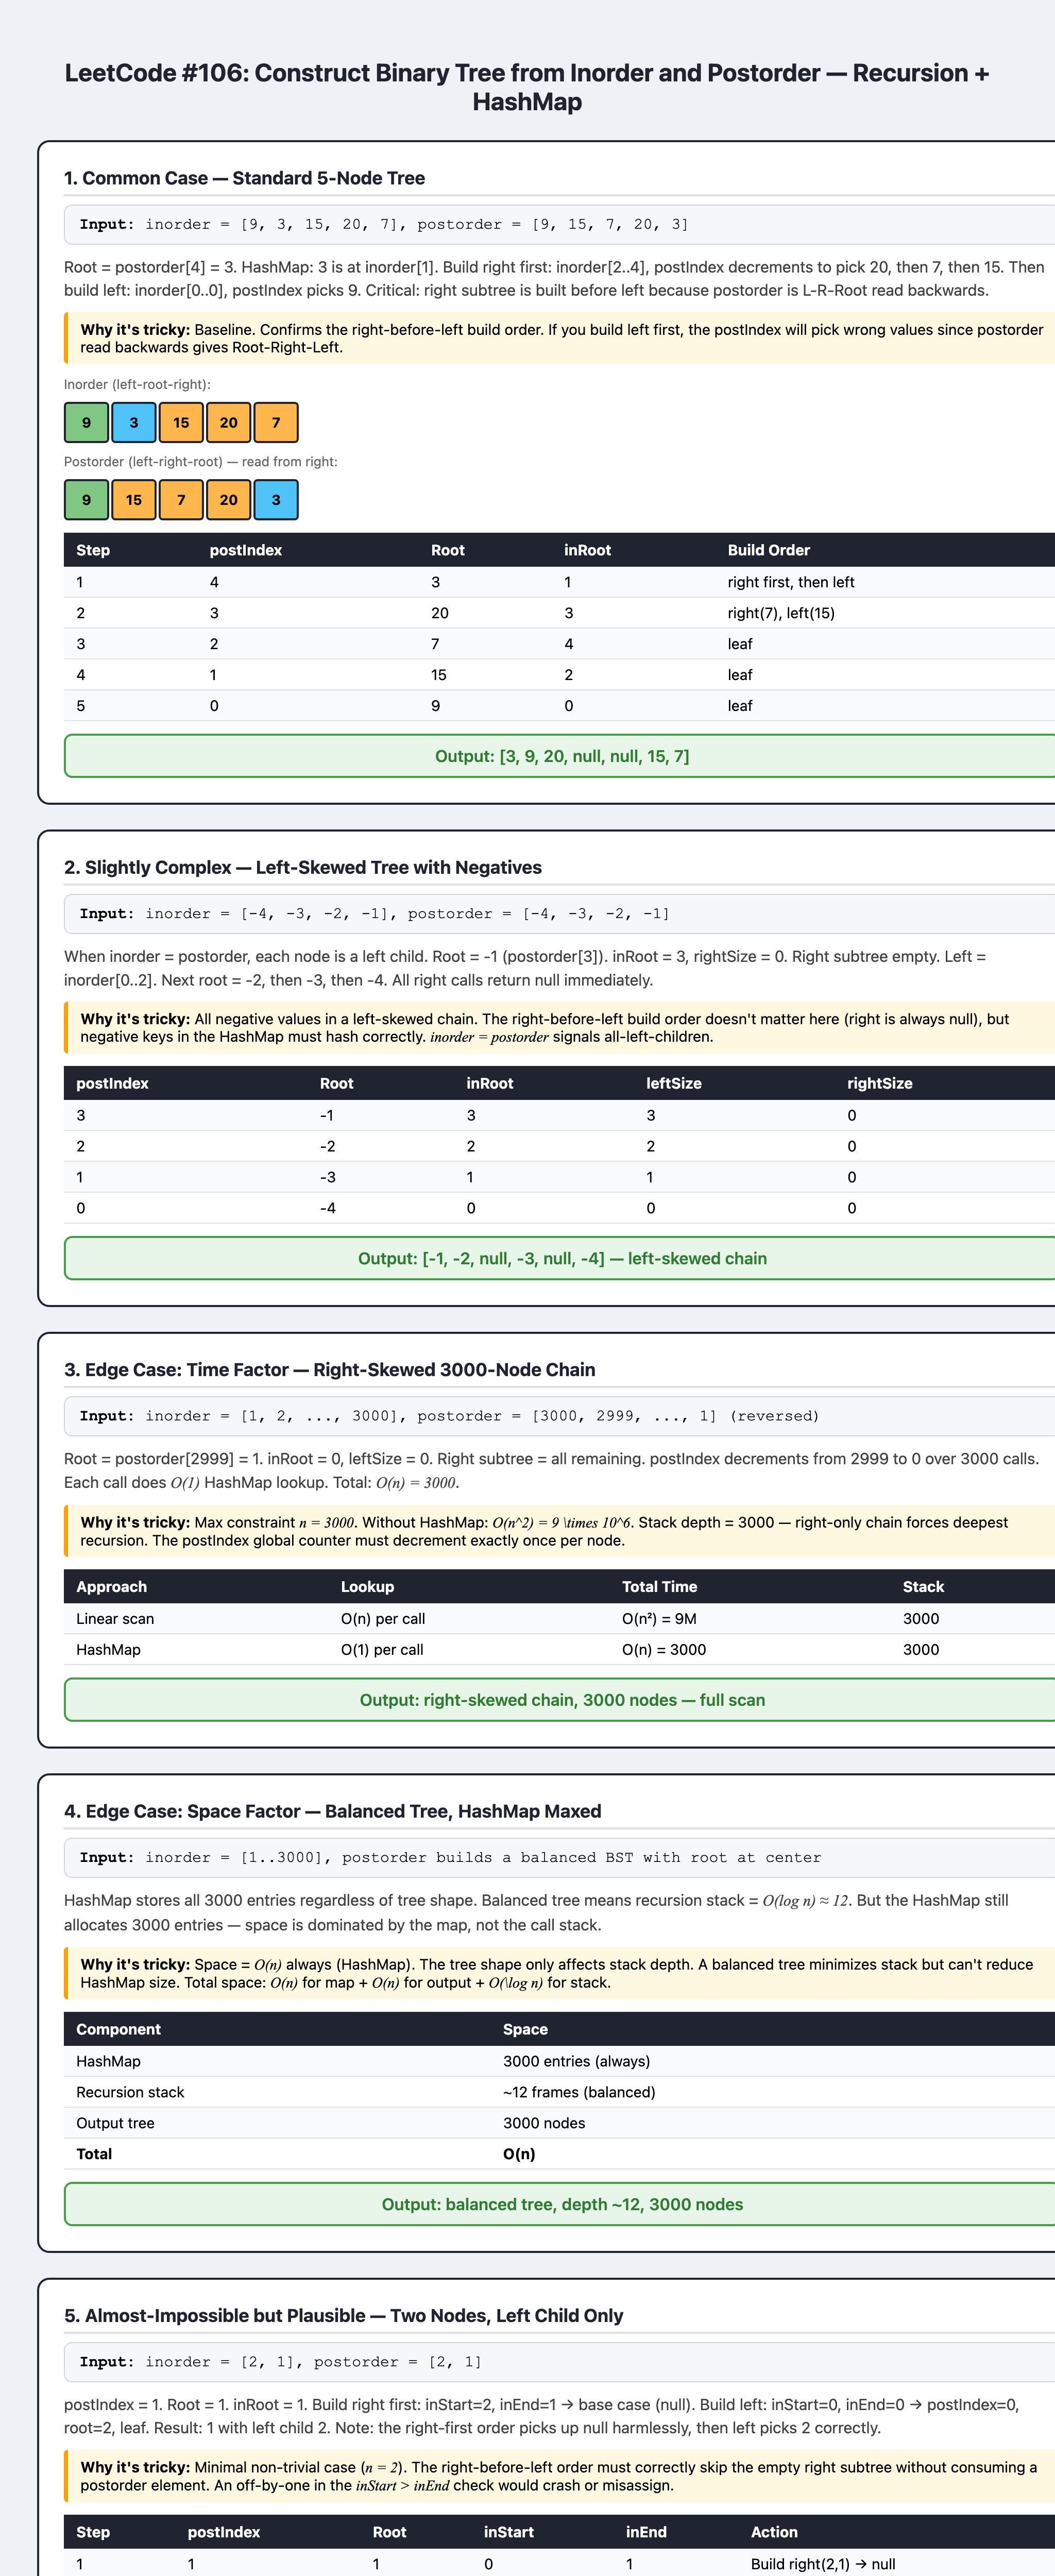